# ITS DT

In [67]:
# Load library
import geopandas as gpd
import pandas as pd
import osmnx as ox
import rasterio
from rasterstats import zonal_stats
import ee
import geemap
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Query campus boundary
boundary = ox.geocode_to_gdf("Institut Teknologi Sepuluh Nopember")

In [3]:
# Query 2D buildings
buildings = ox.features_from_polygon(
    boundary.iloc[0]["geometry"], tags={"building": True}
)

# Remove buildings tagged as point or multipoint
buildings = buildings[
    ~buildings["geometry"].geom_type.isin(["Point", "MultiPoint"])
].reset_index()

# Retain only few attributes for smaller storage
buildings = buildings[["id", "geometry", "building", "name", "building:levels", "height"]]

In [4]:
# Extract median building height from Open Buildings 2.5D
def assign_median_heights(
    building_gdf, raster_path, nodata_val: float = 0.0
):
    """
    Extracts the median raster value for each building footprint.
    """
    # Match CRS
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

    if building_gdf.crs != raster_crs:
        building_gdf = building_gdf.to_crs(raster_crs)

    # Compute zonal statistics
    stats = zonal_stats(
        vectors=building_gdf, raster=raster_path, stats=["median"], nodata=nodata_val
    )

    # Assign to GeoDataFrame
    building_gdf["median_height"] = [stat["median"] for stat in stats]

    # Fallback for very small polygons that missed pixel centroids
    building_gdf["median_height"] = building_gdf["median_height"]

    # Rounded to 2 decimals
    building_gdf["median_height"] = building_gdf["median_height"].round(2)
    
    # Get area
    building_gdf["area"] = building_gdf.area.round(2)

    return building_gdf

buildings = assign_median_heights(
    buildings, raster_path="../data/building_height_raster_2023.tif"
)

In [5]:
# Export
buildings.to_parquet("../data/buildings_w_height.parquet")

In [5]:
# Re-read
buildings = gpd.read_parquet("../data/buildings_w_height.parquet")

## LST Calculation

In [10]:
# Initialize Earth Engine
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()


Successfully saved authorization token.


In [43]:
# Set LST modelling parameter
# Get bounding box
boundary_bbox = boundary.total_bounds
# Boundary box
boundary_bbox = ee.Geometry.BBox(
    boundary_bbox[0],
    boundary_bbox[1],
    boundary_bbox[2],
    boundary_bbox[3]
    )

# Imagery date. October is chosen due to being peak dry season in Surabaya with highest temperature
start = "2023-10-01"
end = "2023-10-31"

# Label
label = "LST"

# Predictors
predictors = [
    "B2",
    "B3",
    "B4",
    "B8",
    "B11",
    "B12",
    "NDMI",
    "NBR",
    "NBR2",
    "NDWI",
    "MNDWI",
    "MNDWI2",
    "elevation",
    "TPI",
    "slope",
    "wetness",
    "greeness",
    "dryness",
]

# RF model config
final_predictor_size = 3
train_test_ratio = 0.7
# Note: LST sampling comes from the underlying L8/L9, with spatial resolution of 30m
# instead of Sentinel-2 10m. To reduce spatial autocorrelation on the sampling, 
# no neighboring pixel should be sampled, minimum distance is every other pixel. 
# Given the size of study area (campus), this would still be spatially autocorrelated, 
# Yet the goal is to mitigate it. 
sampling_scale = 60
num_points = 1000
random_seed = 42

In [23]:
# Data pre-processing
# Cloud masking functions
def cloudMaskLandsat(image):
    qa = image.select("QA_PIXEL")
    # Bit 1 is dilated cloud, 2 is cirrus, 3 is cloud, 4 is cloud shadow
    mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
    )

    return (
        image.select(["ST_B10"], [label])
        .updateMask(mask)
        .multiply(0.00341802)
        .add(149)
        .subtract(273.15)
    )


def cloudMaskS2(image):
    cloud_prob = ee.Image(image.get("cloud_mask"))

    # Keep pixels with cloud probability below 40%
    mask = cloud_prob.lt(40)

    return (
        image
        .updateMask(mask)
        .multiply(1e-4)
    )

In [47]:
# Filter object
date_filter = ee.Filter.date(start, end)
bounds_filter = ee.Filter.bounds(boundary_bbox)

# Landsat LST Composite
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
lstLandsat = (
    l8.filter(bounds_filter)
    .filter(date_filter)
    .merge(l9.filter(bounds_filter).filter(date_filter))
    .map(cloudMaskLandsat)
    .median()
    .clip(boundary_bbox)
)

# Sentinel-2 SR Composite
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")

# Sentinel-2 cloud probability
s2_cloud_prob = ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")

# Join SR images with their corresponding cloud-probability images
s2_joined = ee.Join.saveFirst("cloud_mask").apply(
    primary=s2,
    secondary=s2_cloud_prob,
    condition=ee.Filter.equals(leftField="system:index", rightField="system:index"),
)

s2Image = (
    ee.ImageCollection(s2_joined)
    .filter(bounds_filter)
    .filter(date_filter)
    .map(cloudMaskS2)
    .median()
    .clip(boundary_bbox)
)

# Elevation Data
srtm = ee.Image("USGS/SRTMGL1_003").clip(boundary_bbox)

In [48]:
# Indices calculation
def calculate_indices(image):
    ndmi = image.normalizedDifference(["B8", "B11"]).rename("NDMI")
    nbr = image.normalizedDifference(["B8", "B12"]).rename("NBR")
    nbr2 = image.normalizedDifference(["B11", "B12"]).rename("NBR2")
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    mndwi1 = image.normalizedDifference(["B3", "B11"]).rename("MNDWI")
    mndwi2 = image.normalizedDifference(["B3", "B12"]).rename("MNDWI2")
    return ee.Image([ndmi, nbr, nbr2, ndwi, mndwi1, mndwi2])


indicesImage = calculate_indices(s2Image)

In [49]:
# Stratification of elevation
strat = (
    ee.Image(0)
    .where(srtm.lt(0), 1)
    .where(srtm.gte(0).And(srtm.lt(2)), 2)
    .where(srtm.gte(2).And(srtm.lt(4)), 3)
    .where(srtm.gte(4).And(srtm.lt(6)), 4)
    .where(srtm.gte(6).And(srtm.lt(8)), 5)
    .where(srtm.gte(8).And(srtm.lt(10)), 6)
    .where(srtm.gte(10), 7)
    .selfMask()
    .rename("elevation_class")
)

In [50]:
# Simple land cover and context maps
wet = indicesImage.select("MNDWI2").gt(0)
green = indicesImage.select("NDMI").gt(0.1).And(wet.eq(0))
dry = wet.eq(0).And(green.eq(0))

wetness = wet.focalMean(1, "square", "pixels", 10).rename("wetness")
greeness = green.focalMean(1, "square", "pixels", 10).rename("greeness")
dryness = dry.focalMean(1, "square", "pixels", 10).rename("dryness")

# Topography
topoAverage = srtm.focalMean(5, "square", "pixels")
tpi = srtm.subtract(topoAverage).rename("TPI")
slope = ee.Terrain.slope(srtm).rename("slope")

In [51]:
# Features stack
features = ee.Image(
    [
        s2Image.select(["B2", "B3", "B4", "B8", "B11", "B12"]),
        indicesImage,
        srtm.rename("elevation"),
        tpi,
        slope,
        strat,
        wetness,
        greeness,
        dryness,
    ]
)

In [52]:
# Build training image
training_image = features.addBands(lstLandsat)

In [53]:
# Sample and features selection
sample = training_image.stratifiedSample(
    scale=sampling_scale,
    numPoints=num_points,
    region=boundary_bbox,
    classBand="elevation_class",
    seed=random_seed,
    geometries=True,
    tileScale=4,
)


# Add coordinates to sample
def add_coordinates(feature):

    coords = feature.geometry().coordinates()

    return feature.set({"longitude": coords.get(0), "latitude": coords.get(1)})


sample = sample.map(add_coordinates)

# Feature selection based on correlation
predictorsLst = predictors + ["LST"]

In [ ]:
# Export
# Training sample
task_csv = ee.batch.Export.table.toDrive(
    collection=sample,
    description="ITS_Training_Samples_Oct",
    folder="earthengine",
    fileFormat="CSV",
)

task_csv.start()

# Landsat LST
task_lst = ee.batch.Export.image.toDrive(
    image=lstLandsat.toFloat(),
    description="ITS_Landsat_LST_Composite_Oct",
    folder="earthengine",
    region=boundary_bbox,
    scale=30,
    crs="EPSG:4326",
    maxPixels=1e10,
    formatOptions={"cloudOptimized": True},
)

task_lst.start()

# Sentinel-2
task_s2 = ee.batch.Export.image.toDrive(
    image=s2Image.select(["B2", "B3", "B4", "B8", "B11", "B12"]).toFloat(),
    description="ITS_Sentinel2_Composite_Oct",
    folder="earthengine",
    region=boundary_bbox,
    scale=10,
    crs="EPSG:4326",
    maxPixels=1e10,
    formatOptions={"cloudOptimized": True},
)

task_s2.start()

# Predictor raster
predictor_image = features.select(predictors)


task_predictors = ee.batch.Export.image.toDrive(
    image=predictor_image.toFloat(),
    description="ITS_LST_Predictors_10m_Oct",
    folder="earthengine",
    region=boundary_bbox,
    scale=10,
    crs="EPSG:4326",
    maxPixels=1e10,
    formatOptions={"cloudOptimized": True},
)

task_predictors.start()

In [60]:
# Build random forest model
sample_df = pd.read_csv("../data/ITS_Training_Samples_Oct.csv")

X = sample_df[predictors]
y = sample_df["LST"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R²  = {r2:.4f}")
print(f"MAE = {mae:.4f} °C")


joblib.dump(rf, "../data/ITS_LST_RandomForest_Oct.joblib")

print("Model saved.")

R²  = 0.8443
MAE = 0.6833 °C
Model saved.


In [68]:
# Basic quality metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Mean Error / Bias
bias = np.mean(y_pred - y_test)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")
print(f"Bias : {bias:.4f} °C")

R²   : 0.8443
MAE  : 0.6833 °C
RMSE : 0.8507 °C
Bias : -0.0305 °C


In [69]:
# Feature importance
importance_df = pd.DataFrame(
    {"feature": predictors, "importance": rf.feature_importances_}
)

importance_df = importance_df.sort_values("importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance_df.to_string(index=False))


Random Forest Feature Importance:
  feature  importance
 greeness    0.404463
  dryness    0.272517
     NDMI    0.064353
     NBR2    0.046139
      NBR    0.043380
  wetness    0.029108
       B8    0.021065
       B4    0.015675
       B2    0.012458
     NDWI    0.012169
      TPI    0.011946
      B12    0.011654
       B3    0.011638
    slope    0.010742
      B11    0.010102
   MNDWI2    0.009021
    MNDWI    0.008865
elevation    0.004704


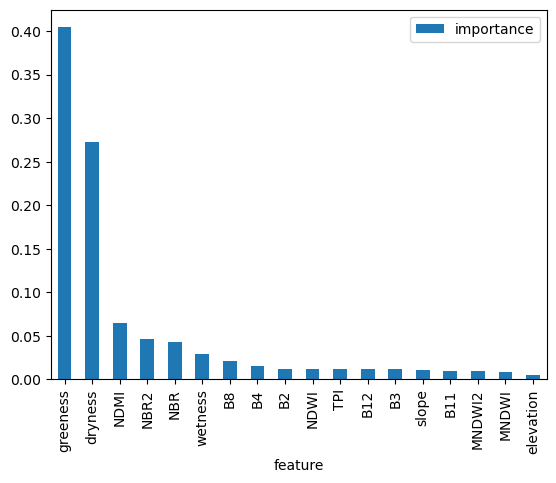

In [75]:
importance_df.plot.bar(x="feature")
plt.show()

In [78]:
# Test the rf model on the whole of study area to get LST image
input_raster = "../data/ITS_LST_Predictors_10m_Oct.tif"
output_raster = "../data/ITS_LST_Prediction_10m_Oct.tif"

# Write output raster
with rasterio.open(input_raster) as src:
    data = src.read().astype(np.float32)
    bands, rows, cols = data.shape

    # Transpose to 2d (rows * cols, bands)
    data_2d = np.transpose(data, (1, 2, 0)).reshape(-1, bands)

    # Handle nodata
    valid_mask = ~np.isnan(data_2d).any(axis=1)

    # Initialize a 1D array for the results, filled with NaNs
    lst_1d = np.full(rows * cols, np.nan, dtype=np.float32)

    # Predict LST only on valid pixels
    if valid_mask.any():
        lst_1d[valid_mask] = rf.predict(data_2d[valid_mask]).astype(np.float32)

    # Reshape back to original 2D raster grid
    lst_2d = lst_1d.reshape(rows, cols)

    # Output metadata
    profile = src.profile.copy()
    profile.update(
        dtype="float32",
        count=1,
        compress="deflate",
        predictor=2,
        nodata=np.nan
    )

    # Write output
    with rasterio.open(output_raster, "w", **profile) as dst:
        dst.write(lst_2d, 1)

c:\Users\Dimas RD\miniconda3\envs\geo_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
